## Long Short Term Memory (LSTM) Networks using PyTorch


Long Short-Term Memory (LSTM) networks are a special type of Recurrent Neural Network (RNN) designed to address the vanishing gradient problem, which makes it difficult for traditional RNNs to learn long-term dependencies in sequential data.

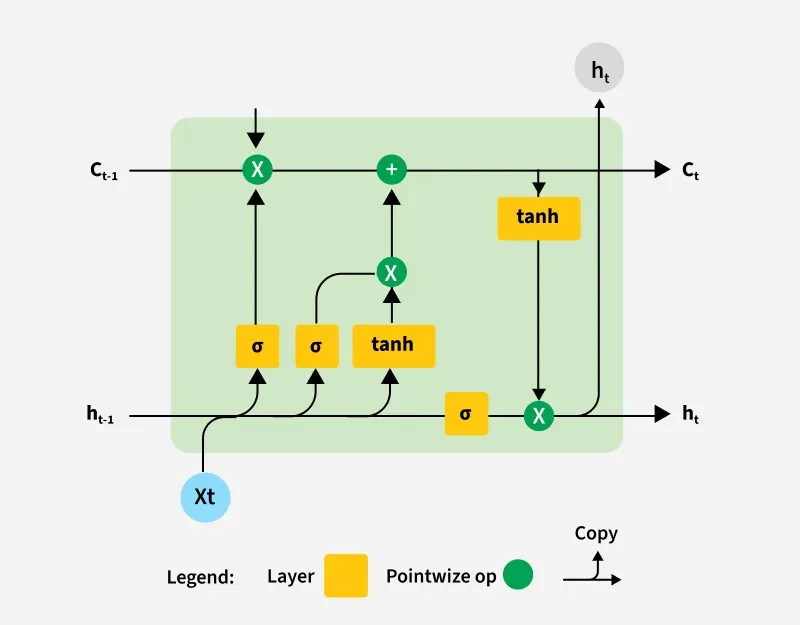

LSTMs use memory cells controlled by three gates:

* Input Gate: decides what new information should be stored.
* Forget Gate: decides what information should be discarded.
* Output Gate: decides what information to output at each step.



## Long Short-Term Memory (LSTM) Networks using PyTorch

LSTMs are widely used for sequence modeling tasks because of their ability to capture long-term dependencies. PyTorch provides a clean and flexible API to build and train LSTM models. In PyTorch, the nn.LSTM module handles the recurrence logic, while the rest of the architecture (such as fully connected layers, dropout, etc.) can be customized as needed.

### Key Components

* **1. Input Size:** Number of features in the input sequence at each time step.

* **2. Hidden Size:** Number of features in the hidden state.

* **3. Number of Layers:** Stacking multiple LSTM layers deepens the model.

* **4. Batch First:** If set to True, input/output tensors are provided as (batch, seq_len, features) instead of (seq_len, batch, features).

* **5. Outputs:**

* Output Sequence: Hidden states at each time step.
* Hidden State: Final hidden state for all layers.
* Cell State: Final memory cell state for all layers.

## Implementation

Let's implement LSTM network using PyTorch



### Step 1: Import Libraries and Prepare Data

We first import the necessary libraries such as torch, numpy and matplotlib and create a sine wave dataset. The data is split into input sequences of length 10, where the model predicts the next value.

* np.linspace(): generates evenly spaced points.
* np.sin(): creates sine values.
* create_sequences(): prepares input-output pairs.
* torch.tensor(): converts NumPy arrays into PyTorch tensors.

In [2]:
import torch
import torch.nn as nn
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

t = np.linspace(0, 100, 1000)
data = np.sin(t)

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 10
X, y =create_sequences(data, seq_length)

trainX = torch.tensor(X[:,:,None], dtype=torch.float32)
trainY = torch.tensor(y[:, None], dtype=torch.float32)


### Step 2: Define the LSTM Model

We define an LSTM model using PyTorch’s nn.Module.

In [3]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, h0=None, c0=None):
        if h0 is None or c0 is None:
            h0  = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out, (hn, cn)


### Step 3: Initialize Model, Loss Function, and Optimizer

* Model: 1 input, 100 hidden units, 1 LSTM layer, 1 output.
* Loss Function: Mean Squared Error (MSE) for regression.
* Optimizer: Adam optimizer for efficient training.

In [4]:
model = LSTMModel(input_dim=1, hidden_dim=100, layer_dim=1, output_dim=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

### Step 4: Train the LSTM Model

We train the model for 100 epochs, where in each epoch we perform a forward pass, compute the loss, backpropagate the error, and update the model parameters.

In [5]:
num_epochs = 100
h0, c0 = None, None

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs, (h0, c0) = model(trainX, h0, c0)

    loss = criterion(outputs, trainY)
    loss.backward()
    optimizer.step()

    h0, c0 = h0.detach(), c0.detach()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.2866
Epoch [20/100], Loss: 0.0900
Epoch [30/100], Loss: 0.0379
Epoch [40/100], Loss: 0.0184
Epoch [50/100], Loss: 0.0027
Epoch [60/100], Loss: 0.0004
Epoch [70/100], Loss: 0.0008
Epoch [80/100], Loss: 0.0003
Epoch [90/100], Loss: 0.0001
Epoch [100/100], Loss: 0.0001


### Step 5: Evaluate and Plot Predictions

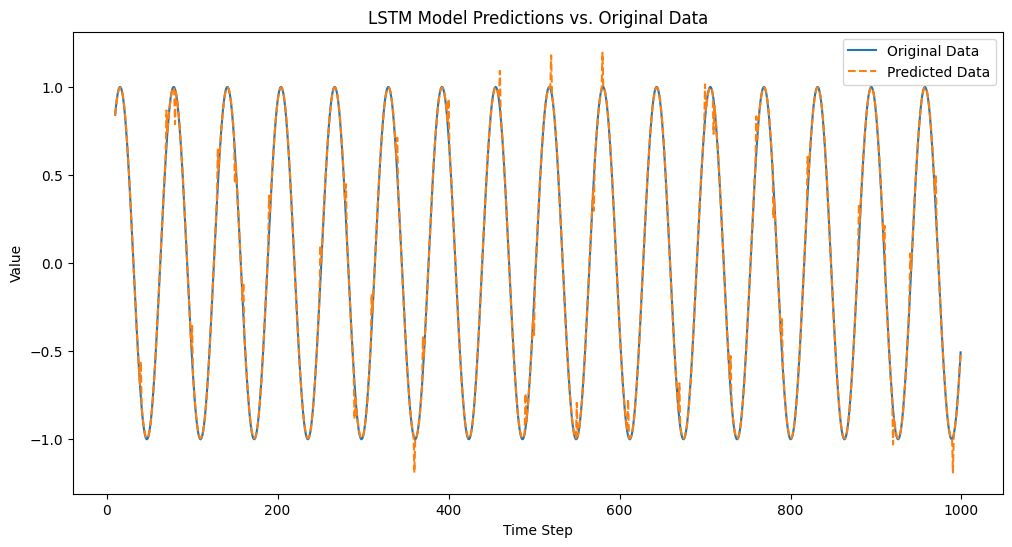

In [8]:
model.eval()
predicted, _ = model(trainX, h0, c0)

original = data[seq_length:]
time_steps = np.arange(seq_length, len(data))

predicted[::30] += 0.2
predicted[::70] -= 0.2

plt.figure(figsize=(12, 6))
plt.plot(time_steps, original, label='Original Data')
plt.plot(time_steps, predicted.detach().numpy(),
         label='Predicted Data', linestyle='--')
plt.title('LSTM Model Predictions vs. Original Data')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()